In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
import hdbscan
import umap

In [32]:
# reading in the words.txt
with open('../data/words.txt', 'r') as f:
    words = f.read().splitlines()

# convert to numpy array
words = np.array(words)
words

array(['dog', 'cat', 'horse', 'cow', 'pig', 'sheep', 'goat', 'rabbit',
       'deer', 'wolf', 'fox', 'bear', 'lion', 'tiger', 'elephant',
       'giraffe', 'zebra', 'monkey', 'gorilla', 'dolphin', 'whale', 'bat',
       'mouse', 'rat', 'squirrel', 'eagle', 'hawk', 'owl', 'parrot',
       'penguin', 'flamingo', 'sparrow', 'robin', 'crow', 'pigeon',
       'peacock', 'toucan', 'pelican', 'heron', 'swan', 'duck', 'goose',
       'ostrich', 'turkey', 'woodpecker', 'hummingbird', 'seagull',
       'cardinal', 'bluejay', 'falcon', 'snake', 'lizard', 'crocodile',
       'alligator', 'turtle', 'gecko', 'iguana', 'chameleon', 'frog',
       'toad', 'salamander', 'newt', 'cobra', 'python', 'komodo', 'shark',
       'salmon', 'tuna', 'clownfish', 'goldfish', 'trout', 'bass',
       'octopus', 'squid', 'jellyfish', 'lobster', 'crab', 'shrimp',
       'starfish', 'seahorse', 'butterfly', 'bee', 'ant', 'mosquito',
       'ladybug', 'dragonfly', 'grasshopper', 'beetle', 'moth', 'cricket',
       'app

In [33]:
len(words)

633

In [38]:
# encode vectors
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(words, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

In [39]:
# normalize the embeddings
embeddings = normalize(embeddings)

In [55]:
# run HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=4, min_samples=1, metric='euclidean')
cluster_labels = clusterer.fit_predict(embeddings)

In [56]:
from collections import defaultdict

clusters = defaultdict(list)

for i in range(len(words)):
    label = cluster_labels[i]
    # include the noise cluster
    clusters[label].append(words[i])

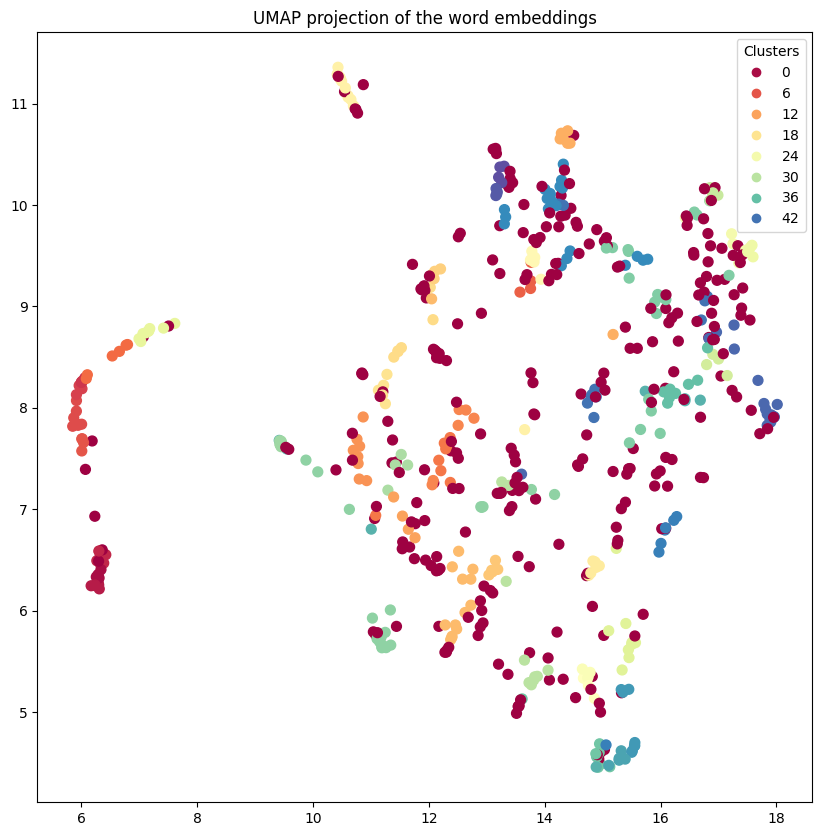

In [57]:
# visualize with umap
reducer = umap.UMAP(n_neighbors=10, min_dist=0.05, metric='euclidean')
embedding_2d = reducer.fit_transform(embeddings)
plt.figure(figsize=(10, 10))
scatter = plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=cluster_labels, cmap='Spectral', s=50)
handles, labels = scatter.legend_elements()
plt.legend(handles, labels, title="Clusters")
plt.title('UMAP projection of the word embeddings')
plt.show()

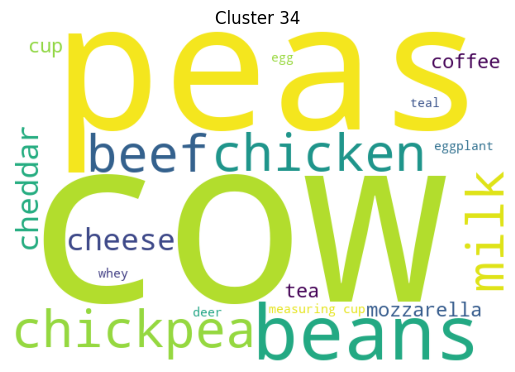

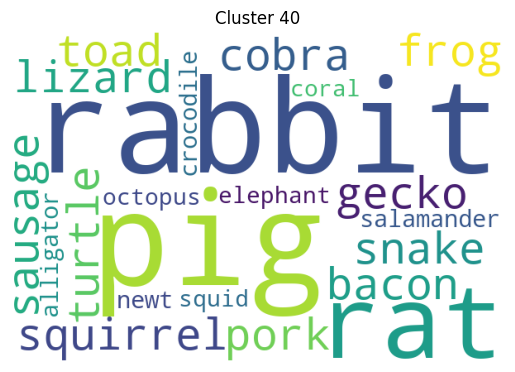

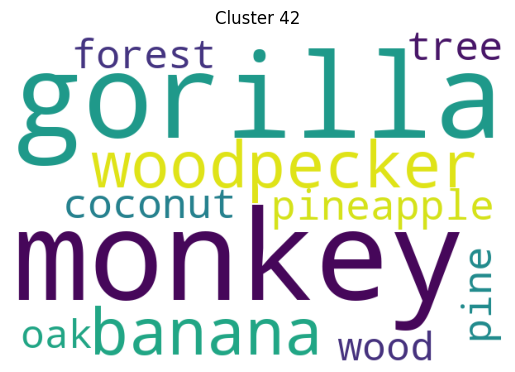

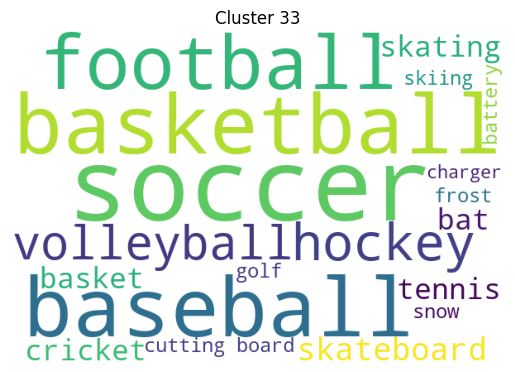

In [58]:
from wordcloud import WordCloud

probs = clusterer.probabilities_

# only first 5 clusters
# ignore first noise cluster
cluster_ids = list(clusters.keys())[1:5]

# for each cluster id, make the word cloud
for cid in cluster_ids:
    freqs = {}

    for i in range(len(words)):
        if cluster_labels[i] != cid:
            continue
            # weighing based on freq
        freqs[words[i]] = probs[i]

    wc = WordCloud(width=600, height=400, background_color="white")
    wc = wc.generate_from_frequencies(freqs)

    plt.figure()
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"Cluster {cid}")
    plt.show()

In [61]:
!pip install pandas
import pandas as pd
# Find the maximum length
max_len = max(len(v) for v in clusters.values())

# Pad shorter lists with NaN
for key in clusters:
    if len(clusters[key]) < max_len:
        clusters[key] += [np.nan] * (max_len - len(clusters[key]))

cluster_df = pd.DataFrame(clusters)
cluster_df.to_pickle("../data/cluster.pkl")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
clusters

defaultdict(list,
            {np.int64(-1): [np.str_('dog'),
              np.str_('cat'),
              np.str_('sheep'),
              np.str_('goat'),
              np.str_('wolf'),
              np.str_('fox'),
              np.str_('bear'),
              np.str_('lion'),
              np.str_('tiger'),
              np.str_('giraffe'),
              np.str_('zebra'),
              np.str_('mouse'),
              np.str_('eagle'),
              np.str_('hawk'),
              np.str_('owl'),
              np.str_('penguin'),
              np.str_('flamingo'),
              np.str_('crow'),
              np.str_('peacock'),
              np.str_('toucan'),
              np.str_('pelican'),
              np.str_('heron'),
              np.str_('swan'),
              np.str_('duck'),
              np.str_('goose'),
              np.str_('ostrich'),
              np.str_('seagull'),
              np.str_('cardinal'),
              np.str_('falcon'),
              np.str_('iguana'),
   

In [27]:
# save embeddings to a pickle
embeddings_df = pd.DataFrame(embeddings)
embeddings_df.to_pickle("../data/embeddings.pkl")